In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()

In [ ]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [ ]:
X = pd.DataFrame(iris.data, columns=iris.feature_names)

In [ ]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
y = pd.DataFrame(iris.target, columns=['species'])

In [ ]:
y.head()

,species
0,0
1,0
2,0
3,0
4,0


In [ ]:
y.species.unique()

array([0, 1, 2])

In [ ]:
y.species.replace({0:'setosa',1:'versicolor',2:'virginica'},inplace=True)

/tmp/ipykernel_12565/1141585655.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  y.species.replace({0:'setosa',1:'versicolor',2:'virginica'},inplace=True)


In [ ]:
y.species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [ ]:
df = pd.concat([X,y],axis=1)

In [ ]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


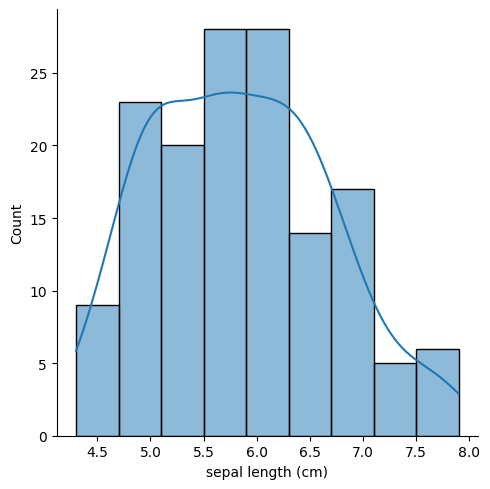

In [ ]:
sns.displot(df['sepal length (cm)'], kde=True);

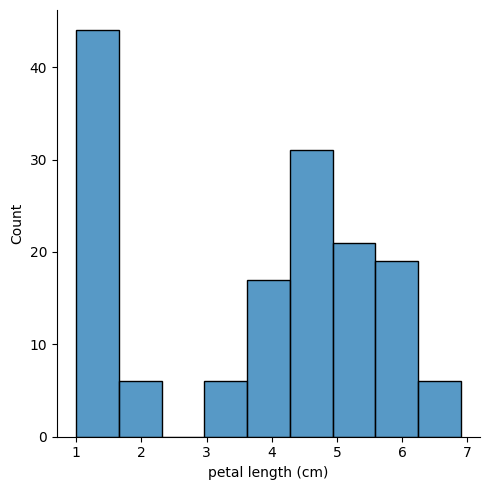

In [ ]:
sns.displot(df['petal length (cm)'])

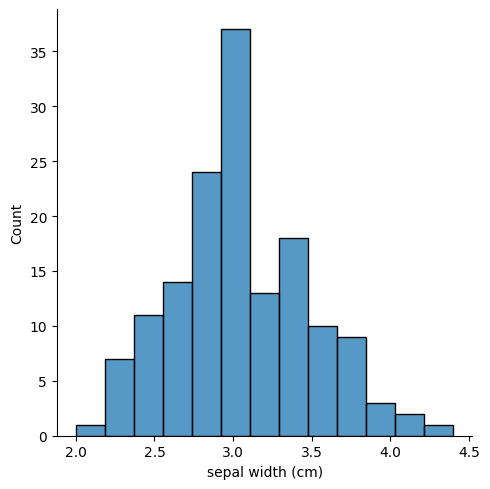

In [ ]:
sns.displot(df['sepal width (cm)'])

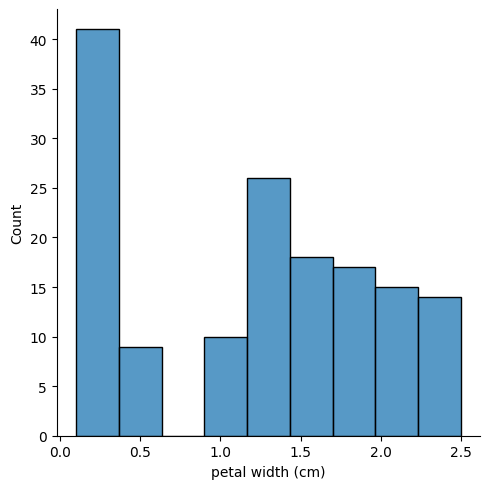

In [ ]:
sns.displot(df['petal width (cm)'])

<Axes: ylabel='species'>

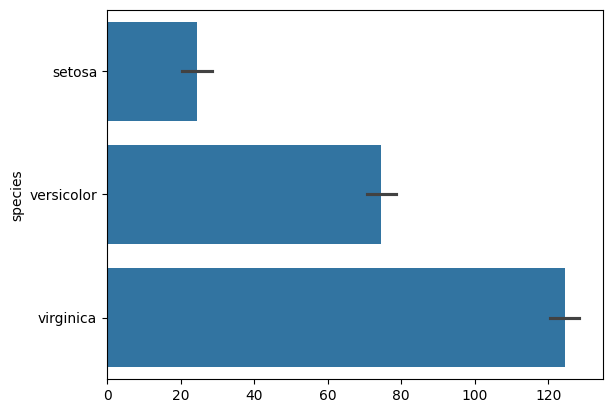

In [ ]:
sns.barplot(df['species'])

In [ ]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns=['species'],axis=1)
y = df['species']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(120, 4)

In [ ]:
X_test.shape

(30, 4)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

In [ ]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = knn.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
acc = accuracy_score(y_test,y_pred)

In [ ]:
print(f'your accuracy is {acc:.2f}')

your accuracy is 1.00
